In [ ]:
!pip install -q "lerobot[dataset]==0.6.0"


In [ ]:
import lerobot
import torch

print("LeRobot import 성공")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 15.7 MB/s eta 0:00:00


In [ ]:
import lerobot
import torch

print("LeRobot import 성공")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

LeRobot import 성공
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

repo_id = "lerobot/aloha_sim_insertion_human"

dataset = LeRobotDataset(repo_id)

print(dataset)
print("데이터 길이:", len(dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

LeRobotDataset({
    Repository ID: 'lerobot/aloha_sim_insertion_human',
    Number of selected episodes: '50',
    Number of selected samples: '25000',
    Features: '['observation.images.top', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.done', 'index', 'task_index']',
})
데이터 길이: 25000


In [ ]:
sample = dataset[0]

print("샘플 키:")
for key in sample.keys():
    value = sample[key]

    if hasattr(value, "shape"):
        print(f"- {key}: shape={tuple(value.shape)}, dtype={value.dtype}")
    else:
        print(f"- {key}: {type(value)}")

샘플 키:
- observation.images.top: shape=(3, 480, 640), dtype=torch.float32
- observation.state: shape=(14,), dtype=torch.float32
- action: shape=(14,), dtype=torch.float32
- episode_index: shape=(), dtype=torch.int64
- frame_index: shape=(), dtype=torch.int64
- timestamp: shape=(), dtype=torch.float32
- next.done: shape=(), dtype=torch.bool
- index: shape=(), dtype=torch.int64
- task_index: shape=(), dtype=torch.int64
- task: <class 'str'>


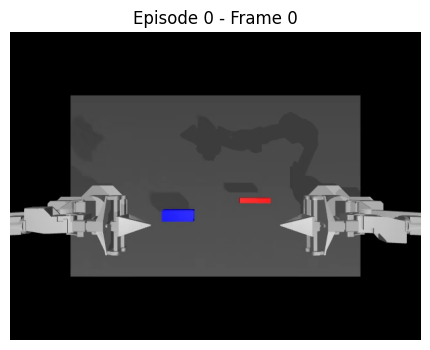

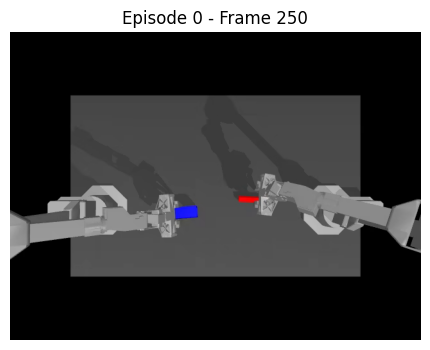

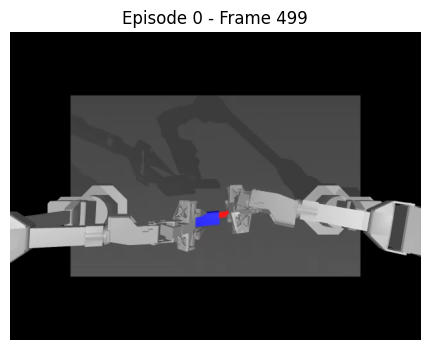

In [ ]:
import matplotlib.pyplot as plt

indices = [0, 250, 499]

for idx in indices:
    image = dataset[idx]["observation.images.top"]
    image = image.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.title(f"Episode 0 - Frame {idx}")
    plt.axis("off")
    plt.show()

In [ ]:
episode_0_indices = [
    i for i in range(len(dataset))
    if int(dataset[i]["episode_index"]) == 0
]

print("Episode 0 frame 수:", len(episode_0_indices))
print("시작 timestamp:", float(dataset[episode_0_indices[0]]["timestamp"]))
print("종료 timestamp:", float(dataset[episode_0_indices[-1]]["timestamp"]))

Episode 0 frame 수: 500
시작 timestamp: 0.0
종료 timestamp: 9.979999542236328


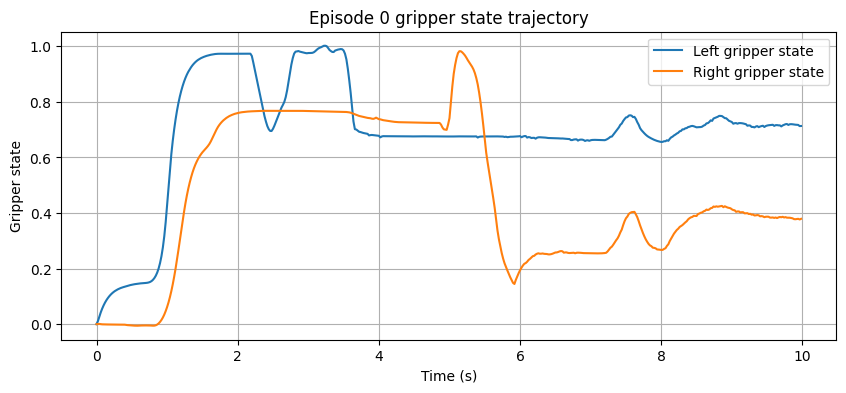

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

states = []
actions = []
timestamps = []

for idx in episode_0_indices:
    sample = dataset[idx]
    states.append(sample["observation.state"].cpu().numpy())
    actions.append(sample["action"].cpu().numpy())
    timestamps.append(float(sample["timestamp"]))

states = np.stack(states)
actions = np.stack(actions)
timestamps = np.array(timestamps)

plt.figure(figsize=(10, 4))
plt.plot(timestamps, states[:, 6], label="Left gripper state")
plt.plot(timestamps, states[:, 13], label="Right gripper state")
plt.xlabel("Time (s)")
plt.ylabel("Gripper state")
plt.title("Episode 0 gripper state trajectory")
plt.legend()
plt.grid(True)
plt.show()

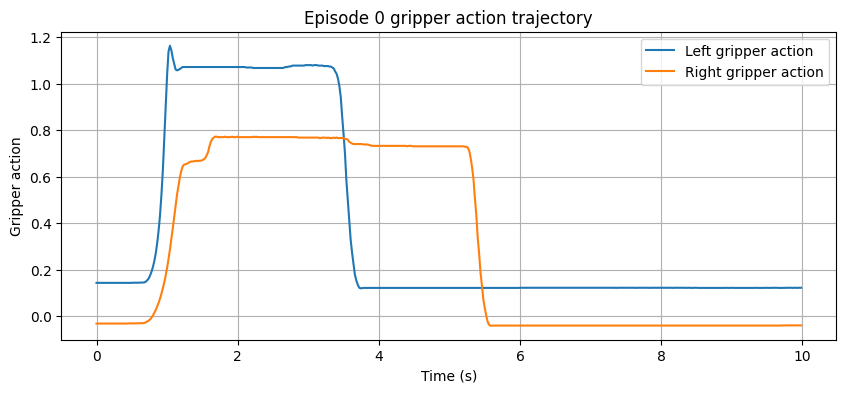

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(timestamps, actions[:, 6], label="Left gripper action")
plt.plot(timestamps, actions[:, 13], label="Right gripper action")
plt.xlabel("Time (s)")
plt.ylabel("Gripper action")
plt.title("Episode 0 gripper action trajectory")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("State shape:", states.shape)
print("Action shape:", actions.shape)

print("\nState min:")
print(states.min(axis=0))

print("\nState max:")
print(states.max(axis=0))

print("\nAction min:")
print(actions.min(axis=0))

print("\nAction max:")
print(actions.max(axis=0))

print("\nNaN in state:", np.isnan(states).sum())
print("NaN in action:", np.isnan(actions).sum())

State shape: (500, 14)
Action shape: (500, 14)

State min:
[-0.09587118 -0.96        0.46316558 -0.10800052 -0.30803946 -0.12798546
  0.         -0.32831132 -0.96        0.25443676 -0.05323189 -0.3
 -0.42962936 -0.00560117]

State max:
[ 0.02166901 -0.05065247  1.1818997   0.0632696   0.8525798   0.
  1.0018015   0.          0.10505544  1.1625555   0.47497892  1.0287305
  0.13024619  0.9820493 ]

Action min:
[-0.0966408  -0.9341943   0.45866027 -0.10737866 -0.31753403 -0.12732041
  0.12005249 -0.32213598 -0.958738    0.25003886 -0.05215535 -0.29912627
 -0.42184472 -0.04060394]

Action max:
[ 0.02454369 -0.05215535  1.1780972   0.06596117  0.85135937 -0.00306796
  1.1624637  -0.00460194  0.1043107   1.1596895   0.48473793  1.0277672
  0.13038836  0.7716878 ]

NaN in state: 0
NaN in action: 0


In [ ]:
from collections import Counter

episode_ids = [
    int(dataset[i]["episode_index"])
    for i in range(len(dataset))
]

episode_lengths = Counter(episode_ids)

print("에피소드 수:", len(episode_lengths))
print("최소 길이:", min(episode_lengths.values()))
print("최대 길이:", max(episode_lengths.values()))
print("평균 길이:", sum(episode_lengths.values()) / len(episode_lengths))

에피소드 수: 50
최소 길이: 500
최대 길이: 500
평균 길이: 500.0


In [15]:
import numpy as np
import matplotlib.pyplot as plt

episode_gripper_states = []

for ep in range(50):
    start_idx = int(dataset.meta.episodes["dataset_from_index"][ep])
    end_idx = int(dataset.meta.episodes["dataset_to_index"][ep])

    ep_grippers = []

    for i in range(start_idx, end_idx):
        state = dataset[i]["observation.state"].cpu().numpy()
        ep_grippers.append(state[[6, 13]])

    episode_gripper_states.append(np.stack(ep_grippers))

episode_gripper_states = np.stack(episode_gripper_states)

print("전체 gripper trajectory shape:", episode_gripper_states.shape)

전체 gripper trajectory shape: (50, 500, 2)


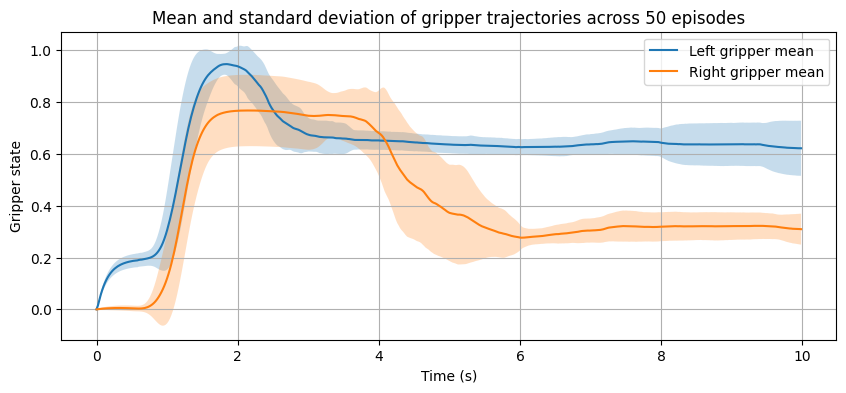

In [16]:
time = np.arange(500) / 50.0

left_mean = episode_gripper_states[:, :, 0].mean(axis=0)
left_std = episode_gripper_states[:, :, 0].std(axis=0)

right_mean = episode_gripper_states[:, :, 1].mean(axis=0)
right_std = episode_gripper_states[:, :, 1].std(axis=0)

plt.figure(figsize=(10, 4))

plt.plot(time, left_mean, label="Left gripper mean")
plt.fill_between(
    time,
    left_mean - left_std,
    left_mean + left_std,
    alpha=0.25
)

plt.plot(time, right_mean, label="Right gripper mean")
plt.fill_between(
    time,
    right_mean - right_std,
    right_mean + right_std,
    alpha=0.25
)

plt.xlabel("Time (s)")
plt.ylabel("Gripper state")
plt.title("Mean and standard deviation of gripper trajectories across 50 episodes")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
all_states = []
all_actions = []

for i in range(len(dataset)):
    all_states.append(dataset[i]["observation.state"].cpu().numpy())
    all_actions.append(dataset[i]["action"].cpu().numpy())

all_states = np.stack(all_states)
all_actions = np.stack(all_actions)

print("전체 state shape:", all_states.shape)
print("전체 action shape:", all_actions.shape)
print("State NaN:", np.isnan(all_states).sum())
print("Action NaN:", np.isnan(all_actions).sum())
print("State min:", all_states.min(axis=0))
print("State max:", all_states.max(axis=0))
print("Action min:", all_actions.min(axis=0))
print("Action max:", all_actions.max(axis=0))

전체 state shape: (25000, 14)
전체 action shape: (25000, 14)
State NaN: 0
Action NaN: 0
State min: [-0.28605697 -0.96        0.30669677 -0.26362535 -0.49300948 -0.42267004
  0.         -0.47746226 -0.99055576  0.09440229 -0.22565386 -0.4322196
 -0.8460991  -0.01209608]
State max: [0.3167214  0.07532272 1.203116   0.2756939  0.99975324 0.44105732
 1.0911053  0.3204266  0.20700689 1.2157615  0.80689096 1.1542442
 0.50637746 1.0758002 ]
Action min: [-0.2883884  -0.95567006  0.30219424 -0.26537868 -0.5445632  -0.41417482
  0.08270375 -0.47246608 -0.99401957  0.08897088 -0.22089323 -0.44485444
 -0.8452234  -0.06495711]
Action max: [0.31753403 0.08436894 1.2225827  0.2807185  0.9986215  0.44178647
 1.1624637  0.320602   0.20555343 1.2118448  0.7056312  1.1458837
 0.480136   0.95406395]


In [18]:
mae_per_dim = np.mean(np.abs(actions - states), axis=0)

joint_names = [
    "left_waist", "left_shoulder", "left_elbow",
    "left_forearm_roll", "left_wrist_angle",
    "left_wrist_rotate", "left_gripper",
    "right_waist", "right_shoulder", "right_elbow",
    "right_forearm_roll", "right_wrist_angle",
    "right_wrist_rotate", "right_gripper"
]

for name, mae in zip(joint_names, mae_per_dim):
    print(f"{name}: MAE={mae:.4f}")

left_waist: MAE=0.0051
left_shoulder: MAE=0.0109
left_elbow: MAE=0.0073
left_forearm_roll: MAE=0.0051
left_wrist_angle: MAE=0.0161
left_wrist_rotate: MAE=0.0028
left_gripper: MAE=0.4149
right_waist: MAE=0.0090
right_shoulder: MAE=0.0141
right_elbow: MAE=0.0105
right_forearm_roll: MAE=0.0176
right_wrist_angle: MAE=0.0165
right_wrist_rotate: MAE=0.0035
right_gripper: MAE=0.1977


In [19]:
plt.savefig("gripper_variability_50episodes.png", dpi=200, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

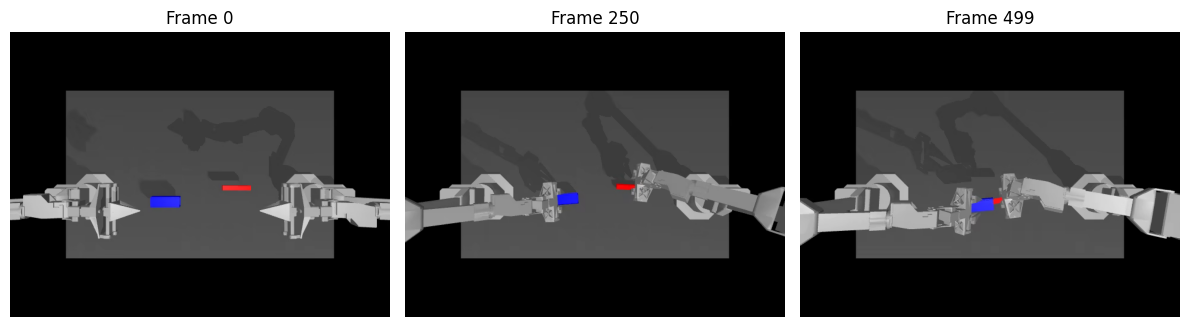

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx in zip(axes, [0, 250, 499]):
    image = dataset[idx]["observation.images.top"]
    image = image.permute(1, 2, 0).cpu().numpy()
    ax.imshow(image)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("episode0_keyframes.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
mae_per_dim_all = np.mean(np.abs(all_actions - all_states), axis=0)

for name, mae in zip(joint_names, mae_per_dim_all):
    print(f"{name}: MAE={mae:.4f}")

left_waist: MAE=0.0050
left_shoulder: MAE=0.0104
left_elbow: MAE=0.0075
left_forearm_roll: MAE=0.0065
left_wrist_angle: MAE=0.0166
left_wrist_rotate: MAE=0.0022
left_gripper: MAE=0.3795
right_waist: MAE=0.0082
right_shoulder: MAE=0.0141
right_elbow: MAE=0.0094
right_forearm_roll: MAE=0.0157
right_wrist_angle: MAE=0.0180
right_wrist_rotate: MAE=0.0035
right_gripper: MAE=0.1916


In [22]:
plt.savefig(
    "gripper_variability_50episodes.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

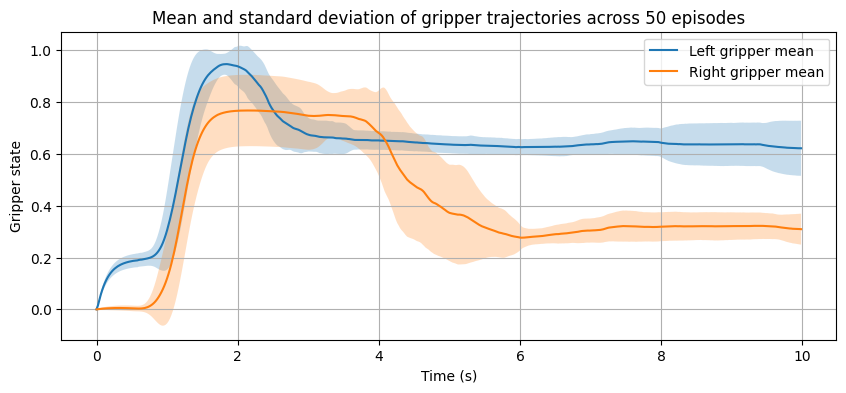

In [23]:
time = np.arange(episode_gripper_states.shape[1]) / 50.0

left_mean = episode_gripper_states[:, :, 0].mean(axis=0)
left_std = episode_gripper_states[:, :, 0].std(axis=0)

right_mean = episode_gripper_states[:, :, 1].mean(axis=0)
right_std = episode_gripper_states[:, :, 1].std(axis=0)

plt.figure(figsize=(10, 4))

plt.plot(time, left_mean, label="Left gripper mean")
plt.fill_between(
    time,
    left_mean - left_std,
    left_mean + left_std,
    alpha=0.25,
)

plt.plot(time, right_mean, label="Right gripper mean")
plt.fill_between(
    time,
    right_mean - right_std,
    right_mean + right_std,
    alpha=0.25,
)

plt.xlabel("Time (s)")
plt.ylabel("Gripper state")
plt.title("Mean and standard deviation of gripper trajectories across 50 episodes")
plt.legend()
plt.grid(True)

plt.savefig(
    "gripper_variability_50episodes.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [24]:
import os

print(os.path.exists("gripper_variability_50episodes.png"))
print(os.path.getsize("gripper_variability_50episodes.png"))

True
120603


**step3**

In [25]:
import torch
import lerobot
import sys

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("LeRobot:", getattr(lerobot, "__version__", "unknown"))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
LeRobot: 0.6.0
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [26]:
!lerobot-train --help | head -n 80

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
usage: lerobot-train [-h] [--config_path str] [--dataset str]
                     [--dataset.repo_id str] [--dataset.root [str]]
                     [--dataset.episodes [List]] [--image_transforms str]
                     [--dataset.image_transforms.enable bool]
                     [--dataset.image_transforms.max_num_transforms int]
                     [--dataset.image_transforms.random_order bool]
                     [--dataset.image_transforms.tfs Dict]
                     [--dataset.revision [str]]
                     [--dataset.use_imagenet_stats bool]
                     [--dataset.video_backend str]
                     [--dataset.return_uint8 bool]
                     [--dat

In [27]:
# LeRobot 0.6.0은 첫 번째 셀에서 설치됨
import lerobot
print("LeRobot version:", getattr(lerobot, "__version__", "0.6.0"))


In [30]:
%%time

!lerobot-train \
  --dataset.repo_id=lerobot/aloha_sim_insertion_human \
  --policy.type=act \
  --output_dir=outputs/act_insertion_300steps \
  --job_name=act_insertion_300steps \
  --policy.device=cuda \
  --policy.push_to_hub=false \
  --batch_size=8 \
  --steps=300 \
  --log_freq=10 \
  --save_freq=300 \
  --wandb.enable=false

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
INFO 2026-07-23 10:31:01 ot_train.py:232 {'batch_size': 8,
 'checkpoint_path': None,
 'cudnn_deterministic': False,
 'dataset': {'depth_output_unit': 'mm',
             'episodes': None,
             'eval_split': 0.0,
             'image_transforms': {'enable': False,
                                  'max_num_transforms': 3,
                                  'random_order': False,
                                  'tfs': {'affine': {'kwargs': {'degrees': [-5.0,
                                                                            5.0],
                                                                'translate': [0.05,
                                                                  

In [31]:
!find outputs/act_insertion_300steps -maxdepth 4 -type f | sort

outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/config.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/model.safetensors
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/policy_postprocessor.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/policy_postprocessor_step_0_unnormalizer_processor.safetensors
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/policy_preprocessor.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/policy_preprocessor_step_3_normalizer_processor.safetensors
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/train_config.json
outputs/act_insertion_300steps/checkpoints/000300/training_state/optimizer_param_groups.json
outputs/act_insertion_300steps/checkpoints/000300/training_state/optimizer_state.safetensors
outputs/act_insertion_300steps/checkpoints/000300/training_state/rng_state.safetensors
outputs/act_insertion_300steps/check

In [32]:
!find outputs/act_insertion_300steps -type f | grep -E "log|json|csv"

outputs/act_insertion_300steps/checkpoints/000300/training_state/optimizer_param_groups.json
outputs/act_insertion_300steps/checkpoints/000300/training_state/training_step.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/config.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/policy_preprocessor.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/train_config.json
outputs/act_insertion_300steps/checkpoints/000300/pretrained_model/policy_postprocessor.json


In [33]:
import torch
from lerobot.policies.act import ACTPolicy

checkpoint_path = (
    "outputs/act_insertion_300steps/"
    "checkpoints/000300/pretrained_model"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

policy = ACTPolicy.from_pretrained(checkpoint_path)
policy = policy.to(device)
policy.eval()

print("Checkpoint loaded")
print("Device:", device)
print("Policy type:", type(policy).__name__)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading weights from local directory
Checkpoint loaded
Device: cuda
Policy type: ACTPolicy


In [34]:
from lerobot.policies import make_pre_post_processors

preprocessor, postprocessor = make_pre_post_processors(
    policy.config,
    pretrained_path=checkpoint_path,
)

print("Preprocessor:", type(preprocessor).__name__)
print("Postprocessor:", type(postprocessor).__name__)

Preprocessor: DataProcessorPipeline
Postprocessor: DataProcessorPipeline


In [35]:
import inspect
from lerobot.policies import make_pre_post_processors

print(inspect.signature(make_pre_post_processors))

(policy_cfg: 'PreTrainedConfig', pretrained_path: 'str | None' = None, pretrained_revision: 'str | None' = None, **kwargs: 'Unpack[ProcessorConfigKwargs]') -> 'tuple[PolicyProcessorPipeline[dict[str, Any], dict[str, Any]], PolicyProcessorPipeline[PolicyAction, PolicyAction]]'


In [36]:
sample = dataset[0]

observation = {
    "observation.images.top": sample["observation.images.top"]
        .unsqueeze(0)
        .to(device),
    "observation.state": sample["observation.state"]
        .unsqueeze(0)
        .to(device),
}

print("Image shape:", observation["observation.images.top"].shape)
print("State shape:", observation["observation.state"].shape)

Image shape: torch.Size([1, 3, 480, 640])
State shape: torch.Size([1, 14])


In [37]:
with torch.inference_mode():
    processed_observation = preprocessor(observation)
    predicted_action = policy.select_action(processed_observation)
    predicted_action = postprocessor(predicted_action)

print("Predicted action shape:", predicted_action.shape)
print("Predicted action:", predicted_action[0].cpu().numpy())

Predicted action shape: torch.Size([1, 14])
Predicted action: [-0.03276677 -0.33608776  0.9352199  -0.07930629  0.45018196 -0.08909104
  0.90766305 -0.02573095 -0.7312626   0.97010916  0.03899048  0.3404046
  0.17289177  0.71372426]


In [38]:
target_action = sample["action"].cpu().numpy()
pred_action = predicted_action[0].detach().cpu().numpy()

print("Target action:")
print(target_action)

print("\nPredicted action:")
print(pred_action)

print(
    "\nSingle-frame action MAE:",
    float(abs(pred_action - target_action).mean())
)

Target action:
[ 0.00920388 -0.9341943   1.1734953  -0.00460194 -0.31139812 -0.00613592
  0.14357445 -0.00613592 -0.958738    1.1581556   0.01380583 -0.29912627
  0.03374758 -0.03124149]

Predicted action:
[-0.03276677 -0.33608776  0.9352199  -0.07930629  0.45018196 -0.08909104
  0.90766305 -0.02573095 -0.7312626   0.97010916  0.03899048  0.3404046
  0.17289177  0.71372426]

Single-frame action MAE: 0.3246873915195465


**step 4**

In [39]:
import numpy as np
import torch
import time

eval_indices = np.linspace(
    0,
    len(dataset) - 1,
    100,
    dtype=int
)

pred_actions = []
target_actions = []
inference_times = []

policy.eval()

for idx in eval_indices:
    sample = dataset[int(idx)]

    observation = {
        "observation.images.top": (
            sample["observation.images.top"]
            .unsqueeze(0)
            .to(device)
        ),
        "observation.state": (
            sample["observation.state"]
            .unsqueeze(0)
            .to(device)
        ),
    }

    # 이전 action chunk가 다음 샘플에 영향을 주지 않도록 초기화
    if hasattr(policy, "reset"):
        policy.reset()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.inference_mode():
        processed_observation = preprocessor(observation)
        predicted_action = policy.select_action(processed_observation)
        predicted_action = postprocessor(predicted_action)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    pred_actions.append(
        predicted_action[0].detach().cpu().numpy()
    )
    target_actions.append(
        sample["action"].detach().cpu().numpy()
    )
    inference_times.append(elapsed)

pred_actions = np.stack(pred_actions)
target_actions = np.stack(target_actions)
inference_times = np.asarray(inference_times)

print("Prediction shape:", pred_actions.shape)
print("Target shape:", target_actions.shape)

Prediction shape: (100, 14)
Target shape: (100, 14)


In [40]:
overall_mae = np.mean(
    np.abs(pred_actions - target_actions)
)

overall_rmse = np.sqrt(
    np.mean((pred_actions - target_actions) ** 2)
)

mae_per_dim = np.mean(
    np.abs(pred_actions - target_actions),
    axis=0
)

mean_inference_ms = inference_times.mean() * 1000
median_inference_ms = np.median(inference_times) * 1000

print(f"Overall action MAE: {overall_mae:.4f}")
print(f"Overall action RMSE: {overall_rmse:.4f}")
print(f"Mean inference time: {mean_inference_ms:.2f} ms")
print(f"Median inference time: {median_inference_ms:.2f} ms")

Overall action MAE: 0.0935
Overall action RMSE: 0.1636
Mean inference time: 28.24 ms
Median inference time: 27.32 ms


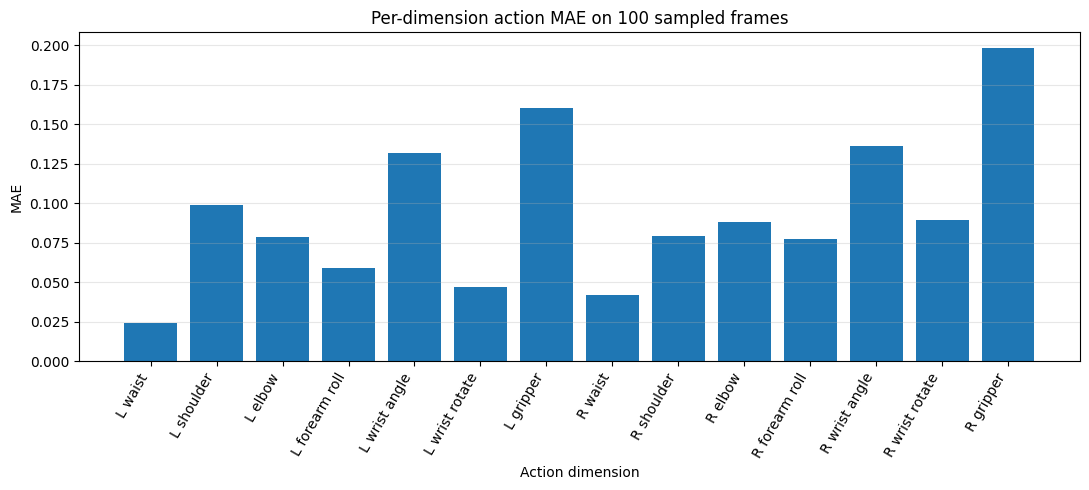

In [41]:
import matplotlib.pyplot as plt

joint_names = [
    "L waist",
    "L shoulder",
    "L elbow",
    "L forearm roll",
    "L wrist angle",
    "L wrist rotate",
    "L gripper",
    "R waist",
    "R shoulder",
    "R elbow",
    "R forearm roll",
    "R wrist angle",
    "R wrist rotate",
    "R gripper",
]

plt.figure(figsize=(11, 5))
plt.bar(joint_names, mae_per_dim)

plt.xlabel("Action dimension")
plt.ylabel("MAE")
plt.title("Per-dimension action MAE on 100 sampled frames")
plt.xticks(rotation=60, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "act_per_dimension_mae.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [42]:
start_idx = int(
    dataset.meta.episodes["dataset_from_index"][0]
)
end_idx = int(
    dataset.meta.episodes["dataset_to_index"][0]
)

episode_indices = list(
    range(start_idx, end_idx, 5)
)

episode_preds = []
episode_targets = []

for idx in episode_indices:
    sample = dataset[idx]

    observation = {
        "observation.images.top": (
            sample["observation.images.top"]
            .unsqueeze(0)
            .to(device)
        ),
        "observation.state": (
            sample["observation.state"]
            .unsqueeze(0)
            .to(device)
        ),
    }

    if hasattr(policy, "reset"):
        policy.reset()

    with torch.inference_mode():
        processed_observation = preprocessor(observation)
        predicted_action = policy.select_action(
            processed_observation
        )
        predicted_action = postprocessor(
            predicted_action
        )

    episode_preds.append(
        predicted_action[0].detach().cpu().numpy()
    )
    episode_targets.append(
        sample["action"].detach().cpu().numpy()
    )

episode_preds = np.stack(episode_preds)
episode_targets = np.stack(episode_targets)

time_axis = (
    np.arange(len(episode_indices)) * 5 / 50
)

print("Episode prediction shape:", episode_preds.shape)

Episode prediction shape: (100, 14)


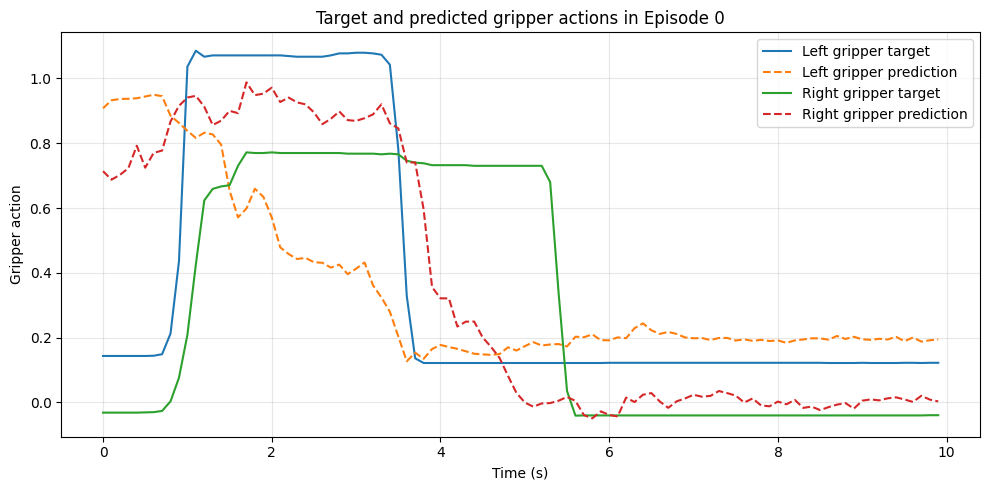

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_axis,
    episode_targets[:, 6],
    label="Left gripper target",
    linestyle="-"
)

plt.plot(
    time_axis,
    episode_preds[:, 6],
    label="Left gripper prediction",
    linestyle="--"
)

plt.plot(
    time_axis,
    episode_targets[:, 13],
    label="Right gripper target",
    linestyle="-"
)

plt.plot(
    time_axis,
    episode_preds[:, 13],
    label="Right gripper prediction",
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Gripper action")
plt.title(
    "Target and predicted gripper actions in Episode 0"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "act_gripper_target_vs_prediction.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [44]:
import numpy as np
import torch
import time

eval_indices = []

for ep in range(50):
    start_idx = int(
        dataset.meta.episodes["dataset_from_index"][ep]
    )
    end_idx = int(
        dataset.meta.episodes["dataset_to_index"][ep]
    )

    ep_indices = np.linspace(
        start_idx,
        end_idx - 1,
        10,
        dtype=int
    )

    eval_indices.extend(ep_indices.tolist())

print("평가 프레임 수:", len(eval_indices))

평가 프레임 수: 500


In [45]:
pred_actions = []
target_actions = []
inference_times = []
episode_ids = []
relative_positions = []

policy.eval()

for idx in eval_indices:
    sample = dataset[int(idx)]

    observation = {
        "observation.images.top": (
            sample["observation.images.top"]
            .unsqueeze(0)
            .to(device)
        ),
        "observation.state": (
            sample["observation.state"]
            .unsqueeze(0)
            .to(device)
        ),
    }

    # 각 프레임을 독립적인 조건으로 평가
    if hasattr(policy, "reset"):
        policy.reset()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.inference_mode():
        processed_observation = preprocessor(observation)
        predicted_action = policy.select_action(
            processed_observation
        )
        predicted_action = postprocessor(
            predicted_action
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    pred_actions.append(
        predicted_action[0].detach().cpu().numpy()
    )
    target_actions.append(
        sample["action"].detach().cpu().numpy()
    )
    inference_times.append(elapsed)

    episode_ids.append(
        int(sample["episode_index"])
    )

    relative_positions.append(
        int(sample["frame_index"]) / 499
    )

pred_actions = np.stack(pred_actions)
target_actions = np.stack(target_actions)
inference_times = np.asarray(inference_times)
episode_ids = np.asarray(episode_ids)
relative_positions = np.asarray(relative_positions)

print("Prediction shape:", pred_actions.shape)
print("Target shape:", target_actions.shape)

Prediction shape: (500, 14)
Target shape: (500, 14)


In [46]:
errors = pred_actions - target_actions
abs_errors = np.abs(errors)

# 1. 전체 MAE
overall_mae = np.mean(abs_errors)

# 2. 전체 RMSE
overall_rmse = np.sqrt(
    np.mean(errors ** 2)
)

# 3. 차원별 MAE
mae_per_dim = np.mean(
    abs_errors,
    axis=0
)

# 4. 정규화 MAE
action_range = (
    all_actions.max(axis=0)
    - all_actions.min(axis=0)
)

safe_action_range = np.where(
    action_range < 1e-8,
    1.0,
    action_range
)

nmae_per_dim = (
    mae_per_dim / safe_action_range
)

overall_nmae = np.mean(nmae_per_dim)

# 5. 14차원 action 방향의 cosine similarity
dot_product = np.sum(
    pred_actions * target_actions,
    axis=1
)

pred_norm = np.linalg.norm(
    pred_actions,
    axis=1
)

target_norm = np.linalg.norm(
    target_actions,
    axis=1
)

cosine_similarity = dot_product / (
    pred_norm * target_norm + 1e-8
)

mean_cosine_similarity = np.mean(
    cosine_similarity
)

# 6. 추론 시간
mean_inference_ms = (
    inference_times.mean() * 1000
)

median_inference_ms = (
    np.median(inference_times) * 1000
)

p95_inference_ms = (
    np.percentile(inference_times, 95) * 1000
)

print(f"Overall MAE: {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")
print(f"Overall NMAE: {overall_nmae:.4f}")
print(
    "Mean cosine similarity:",
    f"{mean_cosine_similarity:.4f}"
)
print(
    "Mean inference time:",
    f"{mean_inference_ms:.2f} ms"
)
print(
    "Median inference time:",
    f"{median_inference_ms:.2f} ms"
)
print(
    "95th percentile latency:",
    f"{p95_inference_ms:.2f} ms"
)

Overall MAE: 0.1039
Overall RMSE: 0.1851
Overall NMAE: 0.0973
Mean cosine similarity: 0.9336
Mean inference time: 16.46 ms
Median inference time: 12.82 ms
95th percentile latency: 38.83 ms


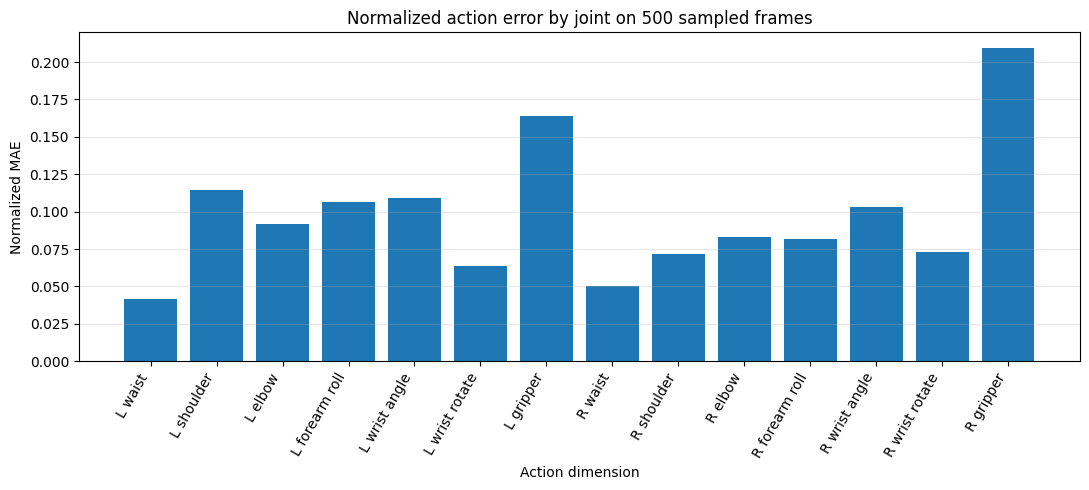

In [47]:
import matplotlib.pyplot as plt

joint_names = [
    "L waist",
    "L shoulder",
    "L elbow",
    "L forearm roll",
    "L wrist angle",
    "L wrist rotate",
    "L gripper",
    "R waist",
    "R shoulder",
    "R elbow",
    "R forearm roll",
    "R wrist angle",
    "R wrist rotate",
    "R gripper",
]

plt.figure(figsize=(11, 5))

plt.bar(
    joint_names,
    nmae_per_dim
)

plt.xlabel("Action dimension")
plt.ylabel("Normalized MAE")
plt.title(
    "Normalized action error by joint "
    "on 500 sampled frames"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "act_normalized_mae_by_joint.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [48]:
phase_names = np.where(
    relative_positions < 1 / 3,
    "Approach / Grasp",
    np.where(
        relative_positions < 2 / 3,
        "Move / Align",
        "Insert / Stabilize"
    )
)

phase_results = {}

for phase in [
    "Approach / Grasp",
    "Move / Align",
    "Insert / Stabilize"
]:
    mask = phase_names == phase

    phase_mae = np.mean(
        np.abs(
            pred_actions[mask]
            - target_actions[mask]
        )
    )

    phase_rmse = np.sqrt(
        np.mean(
            (
                pred_actions[mask]
                - target_actions[mask]
            ) ** 2
        )
    )

    phase_results[phase] = {
        "MAE": phase_mae,
        "RMSE": phase_rmse,
        "count": int(mask.sum())
    }

for phase, result in phase_results.items():
    print(
        phase,
        "| samples:", result["count"],
        "| MAE:", f"{result['MAE']:.4f}",
        "| RMSE:", f"{result['RMSE']:.4f}"
    )

Approach / Grasp | samples: 200 | MAE: 0.1742 | RMSE: 0.2725
Move / Align | samples: 150 | MAE: 0.0722 | RMSE: 0.1087
Insert / Stabilize | samples: 150 | MAE: 0.0419 | RMSE: 0.0580


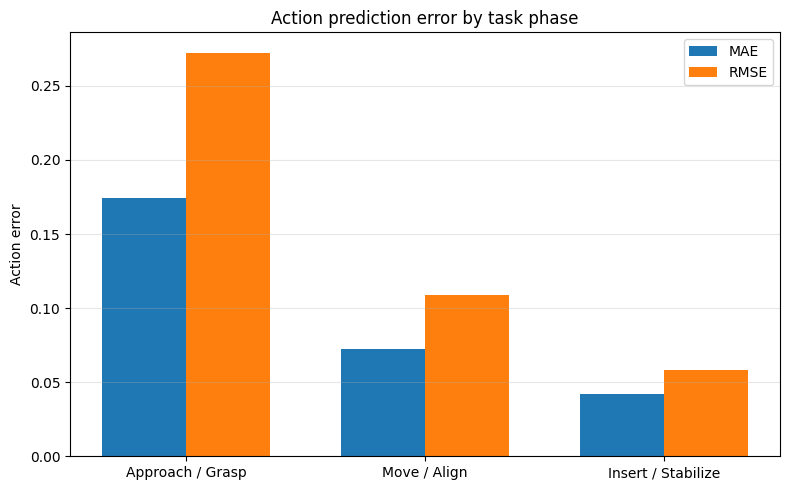

In [49]:
phase_labels = list(
    phase_results.keys()
)

phase_maes = [
    phase_results[p]["MAE"]
    for p in phase_labels
]

phase_rmses = [
    phase_results[p]["RMSE"]
    for p in phase_labels
]

x = np.arange(
    len(phase_labels)
)

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    phase_maes,
    width,
    label="MAE"
)

plt.bar(
    x + width / 2,
    phase_rmses,
    width,
    label="RMSE"
)

plt.xticks(
    x,
    phase_labels
)

plt.ylabel("Action error")
plt.title(
    "Action prediction error by task phase"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "act_error_by_task_phase.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [50]:
episode_id = 0

start_idx = int(
    dataset.meta.episodes[
        "dataset_from_index"
    ][episode_id]
)

end_idx = int(
    dataset.meta.episodes[
        "dataset_to_index"
    ][episode_id]
)

episode_indices = list(
    range(
        start_idx,
        end_idx,
        5
    )
)

episode_preds = []
episode_targets = []

for idx in episode_indices:
    sample = dataset[idx]

    observation = {
        "observation.images.top": (
            sample["observation.images.top"]
            .unsqueeze(0)
            .to(device)
        ),
        "observation.state": (
            sample["observation.state"]
            .unsqueeze(0)
            .to(device)
        ),
    }

    if hasattr(policy, "reset"):
        policy.reset()

    with torch.inference_mode():
        processed_observation = preprocessor(
            observation
        )

        predicted_action = policy.select_action(
            processed_observation
        )

        predicted_action = postprocessor(
            predicted_action
        )

    episode_preds.append(
        predicted_action[0]
        .detach()
        .cpu()
        .numpy()
    )

    episode_targets.append(
        sample["action"]
        .detach()
        .cpu()
        .numpy()
    )

episode_preds = np.stack(
    episode_preds
)

episode_targets = np.stack(
    episode_targets
)

time_axis = (
    np.arange(len(episode_indices))
    * 5 / 50
)

print(
    "Episode prediction shape:",
    episode_preds.shape
)

Episode prediction shape: (100, 14)


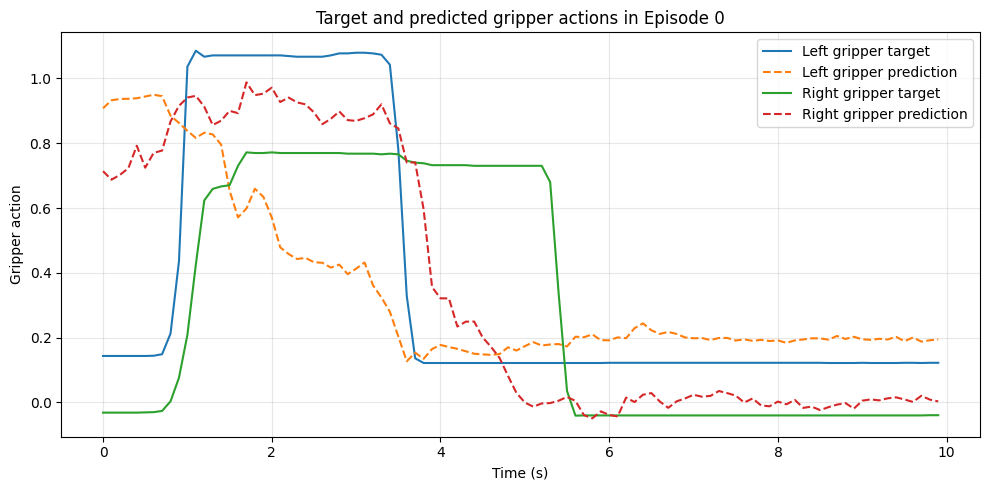

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_axis,
    episode_targets[:, 6],
    label="Left gripper target"
)

plt.plot(
    time_axis,
    episode_preds[:, 6],
    label="Left gripper prediction",
    linestyle="--"
)

plt.plot(
    time_axis,
    episode_targets[:, 13],
    label="Right gripper target"
)

plt.plot(
    time_axis,
    episode_preds[:, 13],
    label="Right gripper prediction",
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Gripper action")

plt.title(
    "Target and predicted gripper "
    "actions in Episode 0"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "act_gripper_target_vs_prediction.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [52]:
correlation_per_dim = []

for dim in range(14):
    target_dim = episode_targets[:, dim]
    pred_dim = episode_preds[:, dim]

    if (
        np.std(target_dim) < 1e-8
        or np.std(pred_dim) < 1e-8
    ):
        corr = np.nan
    else:
        corr = np.corrcoef(
            target_dim,
            pred_dim
        )[0, 1]

    correlation_per_dim.append(corr)

correlation_per_dim = np.asarray(
    correlation_per_dim
)

print(
    "Mean valid correlation:",
    np.nanmean(correlation_per_dim)
)

for name, corr in zip(
    joint_names,
    correlation_per_dim
):
    print(
        f"{name}: correlation={corr:.4f}"
    )

Mean valid correlation: 0.6959183838943318
L waist: correlation=0.6089
L shoulder: correlation=0.9001
L elbow: correlation=0.9005
L forearm roll: correlation=0.8658
L wrist angle: correlation=0.5470
L wrist rotate: correlation=-0.5309
L gripper: correlation=0.4452
R waist: correlation=0.8252
R shoulder: correlation=0.9850
R elbow: correlation=0.9255
R forearm roll: correlation=0.8641
R wrist angle: correlation=0.9037
R wrist rotate: correlation=0.9089
R gripper: correlation=0.5939


In [53]:
target_velocity = np.diff(
    episode_targets,
    axis=0
)

pred_velocity = np.diff(
    episode_preds,
    axis=0
)

velocity_mae = np.mean(
    np.abs(
        pred_velocity
        - target_velocity
    )
)

target_total_variation = np.mean(
    np.sum(
        np.abs(target_velocity),
        axis=0
    )
)

pred_total_variation = np.mean(
    np.sum(
        np.abs(pred_velocity),
        axis=0
    )
)

smoothness_ratio = (
    pred_total_variation
    / (target_total_variation + 1e-8)
)

print(
    f"Velocity MAE: {velocity_mae:.4f}"
)

print(
    "Target total variation:",
    f"{target_total_variation:.4f}"
)

print(
    "Prediction total variation:",
    f"{pred_total_variation:.4f}"
)

print(
    "Smoothness ratio:",
    f"{smoothness_ratio:.4f}"
)

Velocity MAE: 0.0209
Target total variation: 1.1637
Prediction total variation: 1.5926
Smoothness ratio: 1.3686
